# Week 8 Activity: Onset Detection and Autocorrelation

Complete this activity as part of your participation grade. Pending length of the lecture, you will have time in class to work. Everything you need to complete this activity can be found in this week's (or a previous week's) lecture code.

## Onset Detection

Read in the following files below, and normalize.

a) 80sPopDrums.wav  
b) TheBlackKeys_track4.wav (use random 10s from near middle of track)  
c) prelude_cmaj_10s.wav  

In [69]:
import numpy as np
import scipy
# from scipy.io.wavfile import read
from scipy import signal
import matplotlib.pyplot as plt
from IPython.display import Audio
import librosa, librosa.display
from collections import Counter
plt.rcParams['figure.figsize'] = (14, 4)

# a) 80s Pop Drums
(x_drums, fs_drums) = librosa.load('../../audio/80sPopDrums.wav', sr=None)
x_drums = x_drums / np.abs(x_drums).max()

# b) The Black Keys - grab 10s from near the middle
(x_bk_full, fs_bk) = librosa.load('../../audio/TheBlackKeys_track4.wav', sr=None)
mid = len(x_bk_full) // 2
x_bk = x_bk_full[mid : mid + 10 * fs_bk]
x_bk = x_bk / np.abs(x_bk).max()

# c) Prelude C major
(x_pre, fs_pre) = librosa.load('../../audio/prelude_cmaj_10s.wav', sr=None)
x_pre = x_pre / np.abs(x_pre).max()

print(f"Drums: {fs_drums} Hz, {len(x_drums)/fs_drums:.1f}s")
print(f"Black Keys: {fs_bk} Hz, {len(x_bk)/fs_bk:.1f}s")
print(f"Prelude: {fs_pre} Hz, {len(x_pre)/fs_pre:.1f}s")

Drums: 44100 Hz, 8.7s
Black Keys: 44100 Hz, 10.0s
Prelude: 44100 Hz, 10.0s


#### For each of the tracks (start with just one):

1) Compute the energy and RMSE for each track using a frame length of your choice  
2) Plot the energy and the RMSE
3) Use one of the energy features to create your novelty function and plot
4) Write a peak picking function to define onsets from your novelty function
4) Based on the plots, estimate what an appropriate 'threshold' would be. Does the threshold change across tracks? If so, what could you do to put them on a similar scale?

---
### Energy & RMSE — demonstrated on all three tracks

Define a helper that runs the full onset detection pipeline so we can apply it to each file.

In [ ]:
hop_length = 512
frame_length = 1024

def compute_features(x, fs, hop_length=512, frame_length=1024):
    """Compute energy, RMSE, and frame time array for a normalized signal."""
    energy = np.array([
        sum(abs(x[i:i+frame_length]**2))
        for i in range(0, len(x), hop_length)
    ])
    rmse = librosa.feature.rms(
        y=x, frame_length=frame_length, hop_length=hop_length, center=True
    )
    rmse = rmse.squeeze() # remove extra axis
    t = librosa.times_like(rmse, sr=fs) # frame-wise time vector
    return energy, rmse, t

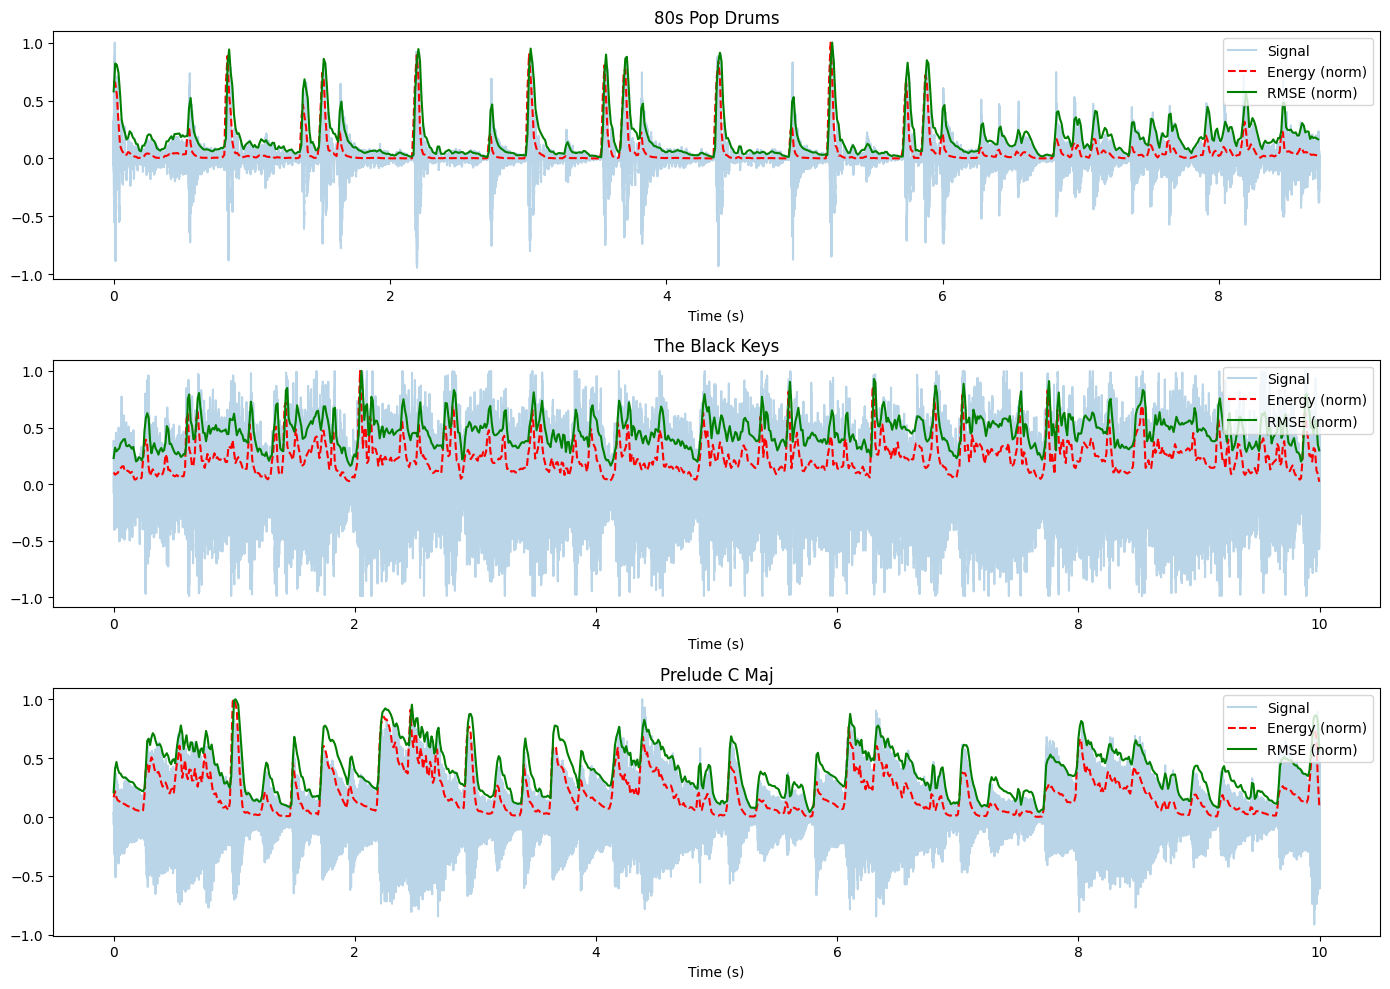

In [147]:
# --- 2) Plot energy and RMSE for each track ---

tracks = [
    ('80s Pop Drums', x_drums, fs_drums),
    ('The Black Keys', x_bk, fs_bk),
    ('Prelude C Maj', x_pre, fs_pre),
]

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for ax, (title, x, fs) in zip(axes, tracks):
    energy, rmse, t = compute_features(x, fs)
    time = np.arange(len(x)) / fs # sample-wise time vector for unframed data
    ax.plot(time, x, alpha=0.3, label='Signal')
    ax.plot(t, energy / energy.max(), 'r--', label='Energy (norm)')
    ax.plot(t, rmse / rmse.max(), 'g', label='RMSE (norm)')
    ax.set_title(title)
    ax.set_xlabel('Time (s)')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Novelty Function

Take the discrete derivative of RMSE and apply half-wave rectification (HWR). HWR keeps only positive increases in energy, since onsets are characterized by energy *rising*.

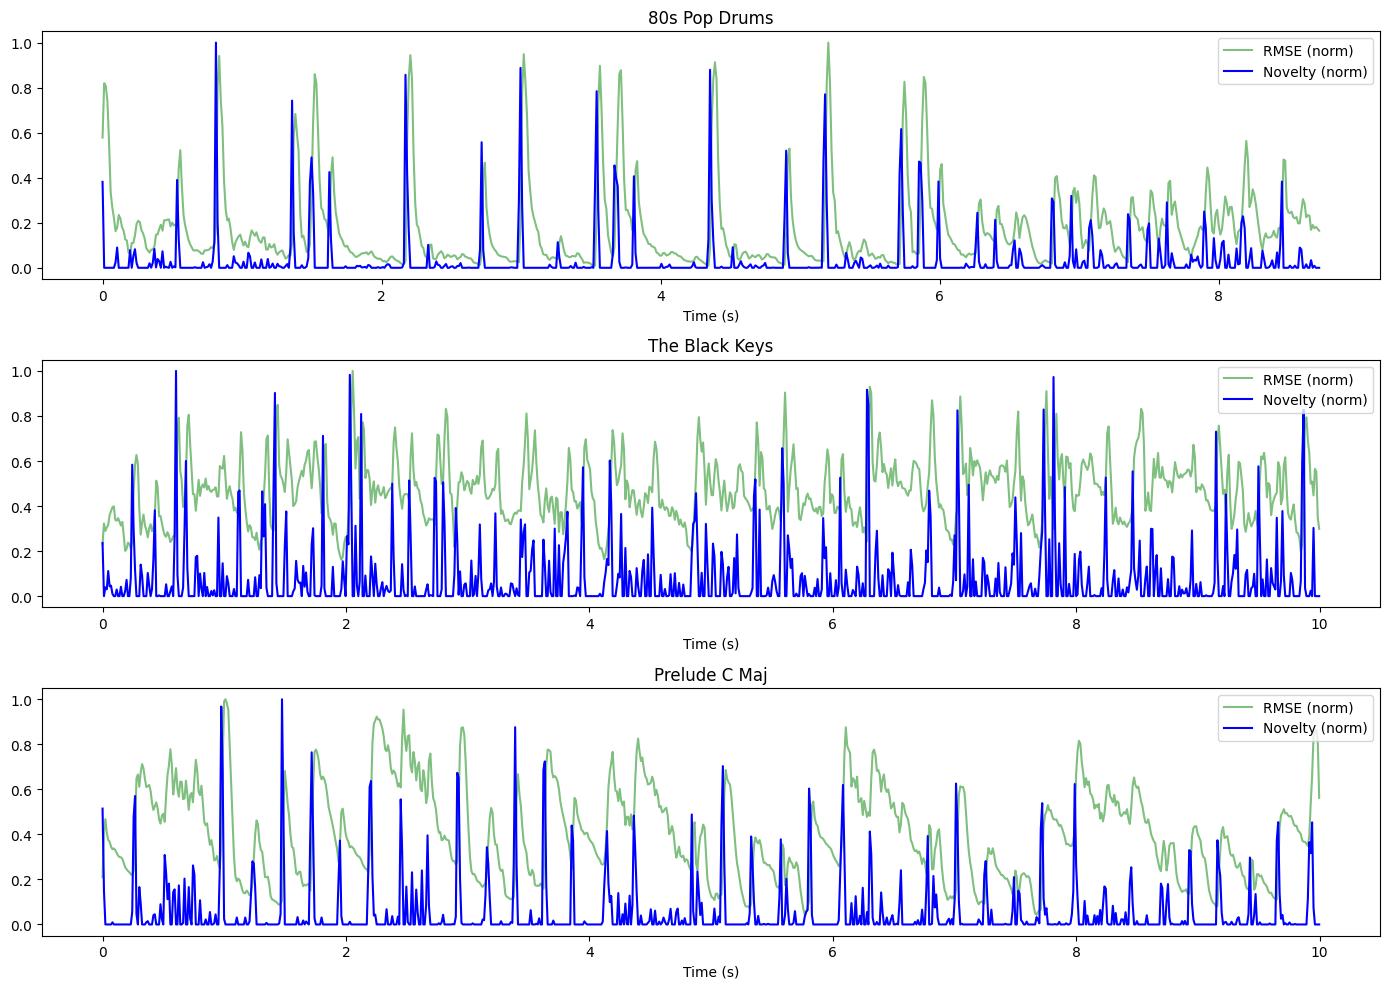

In [ ]:
# --- 3) Novelty function ---

def compute_novelty(rmse):
    rmse_diff = np.diff(rmse)
    novelty = np.concatenate((rmse_diff, np.array([0])))  # pad to keep same length
    novelty[novelty < 0] = 0  # HWR: discard negative energy
    return novelty

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for ax, (title, x, fs) in zip(axes, tracks):
    energy, rmse, t = compute_features(x, fs)
    novelty = compute_novelty(rmse)
    ax.plot(t, rmse / rmse.max(), 'g', alpha=0.5, label='RMSE (norm)')
    ax.plot(t, novelty / novelty.max(), 'b', label='Novelty (norm)')
    ax.set_title(title)
    ax.set_xlabel('Time (s)')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Peak Picking

Use `scipy.signal.find_peaks` with a height threshold to identify onsets. The threshold controls how prominent a peak must be to count as an onset.

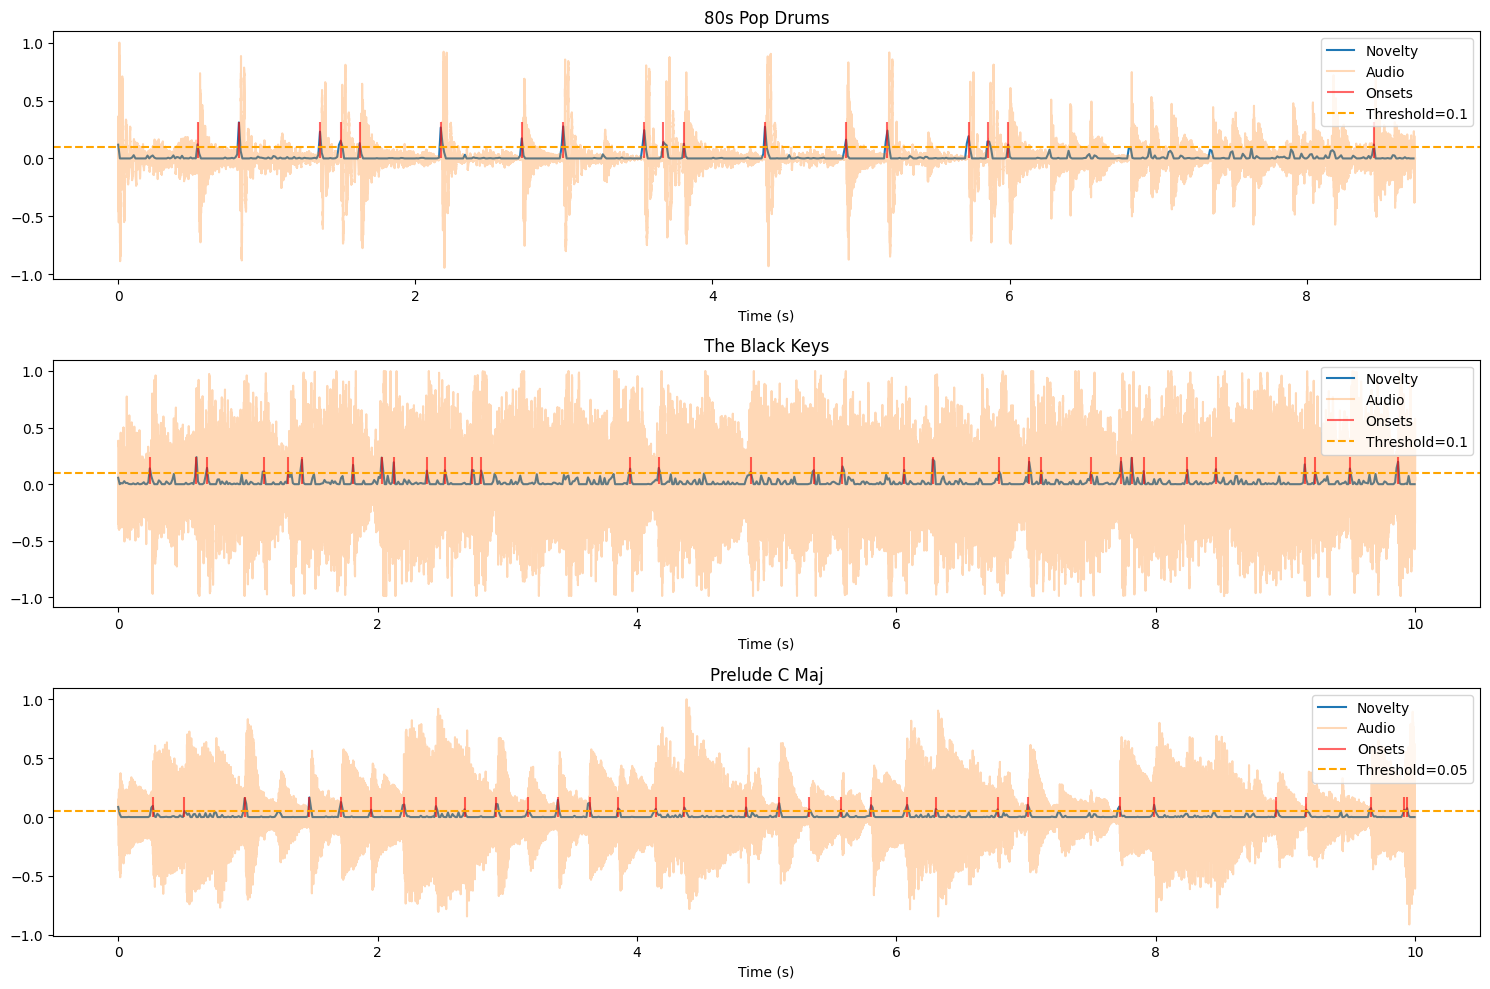

In [ ]:
# --- 4) Peak picking ---
# Thresholds chosen by inspection of the novelty plots above.
# The drums have sharp, consistent peaks so a higher threshold works well.
# The piano prelude has softer transients and needs a lower threshold.
# The dense content of the Black Keys song makes it difficult to balance over-detection and under-detection.

thresholds = {
    '80s Pop Drums':  0.10,
    'The Black Keys': 0.10,
    'Prelude C Maj':  0.05,
}

fig, axes = plt.subplots(3, 1, figsize=(15, 10))

for ax, (title, x, fs) in zip(axes, tracks):
    energy, rmse, t = compute_features(x, fs)
    novelty = compute_novelty(rmse)
    thresh = thresholds[title]

    peaks, _ = signal.find_peaks(novelty, height=thresh)
    peak_times = t[peaks]
    time = np.arange(len(x)) / fs

    ax.plot(t, novelty, label='Novelty')
    ax.plot(time,x, label='Audio', alpha = 0.3)
    ax.vlines(peak_times, 0, novelty.max(), colors='r', alpha=0.6, label='Onsets')
    ax.axhline(thresh, color='orange', linestyle='--', label=f'Threshold={thresh}')
    ax.set_title(title)
    ax.set_xlabel('Time (s)')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()





In [ ]:
# A helper function to help hear the results of our onset detection
def add_onset_beeps(x, fs, onset_times, freq=880, dur=0.04, amp=0.35):
    """Mix a short sine-wave beep into x at each onset time."""
    y = x.copy().astype(float)
    beep_len = int(dur * fs)
    t_beep = np.arange(beep_len) / fs
    beep = amp * np.sin(2 * np.pi * freq * t_beep)
    # exponential fade-out to avoid clicks
    beep *= np.exp(-t_beep / (dur / 3))
    for onset in onset_times:
        start = int(onset * fs)
        end = min(start + beep_len, len(y))
        y[start:end] += beep[:end - start]
    return np.clip(y, -1.0, 1.0)

In [143]:
x_slice = x_bk[:fs_bk * 5]
_, rmse, t = compute_features(x_slice, fs_bk)
novelty = compute_novelty(rmse)
peaks, _ = signal.find_peaks(novelty, height=thresholds['The Black Keys'])
onset_times = t[peaks]
mixed = add_onset_beeps(x_slice, fs_bk, onset_times)
print(f"The Black Keys — {len(onset_times)} onsets detected")
Audio(data=mixed, rate=fs_bk)

The Black Keys — 16 onsets detected


In [144]:
x_slice = x_drums[:fs_drums * 5]
_, rmse, t = compute_features(x_slice, fs_drums)
novelty = compute_novelty(rmse)
peaks, _ = signal.find_peaks(novelty, height=thresholds['80s Pop Drums'])
onset_times = t[peaks]
mixed = add_onset_beeps(x_slice, fs_drums, onset_times)
print(f"80s Pop Drums — {len(onset_times)} onsets detected")
Audio(data=mixed, rate=fs_drums)

80s Pop Drums — 13 onsets detected


In [145]:
x_slice = x_pre[:fs_pre * 5]
_, rmse, t = compute_features(x_slice, fs_pre)
novelty = compute_novelty(rmse)
peaks, _ = signal.find_peaks(novelty, height=thresholds['Prelude C Maj'])
onset_times = t[peaks]
mixed = add_onset_beeps(x_slice, fs_pre, onset_times)
print(f"Prelude C Maj — {len(onset_times)} onsets detected")
Audio(data=mixed, rate=fs_pre)

Prelude C Maj — 17 onsets detected


## Tempo Estimation

Using your novelty functions and detected onsets above, estimate the global tempo of the files using autocorrelation and IOIs.

1) IOI Based Tempo

- Compute Inter-Onset Intervals (IOIs)
- Convert IOIs to BPM
- Create a beat histogram to help you infer tempos

In [ ]:
# --- IOI-Based Tempo (demonstrated on 80s Pop Drums) ---

energy, rmse, t = compute_features(x_drums, fs_drums)
novelty = compute_novelty(rmse)

# Detect onsets (threshold of .1)
peaks, _ = signal.find_peaks(novelty, height=0.10)
peak_times = t[peaks]

# Compute Inter-Onset Intervals
iois = np.diff(peak_times)
print("IOIs (s):", np.round(iois, 3))

# Convert most common IOIs to BPM
num_counts = Counter(np.round(iois, 3))
top_n = num_counts.most_common(3)
print("\nMost common IOIs:", top_n)

for ioi, count in top_n:
    bpm = 60 / ioi
    print(f"  IOI={ioi:.3f}s  →  {bpm:.1f} BPM")

IOIs (s): [0.279 0.546 0.139 0.128 0.546 0.546 0.279 0.546 0.128 0.139 0.546 0.546
 0.279 0.546 0.128 0.139 2.461]

Most common IOIs: [(0.546, 7), (0.279, 3), (0.139, 3)]
  IOI=0.546s  →  109.9 BPM
  IOI=0.279s  →  215.1 BPM
  IOI=0.139s  →  431.7 BPM


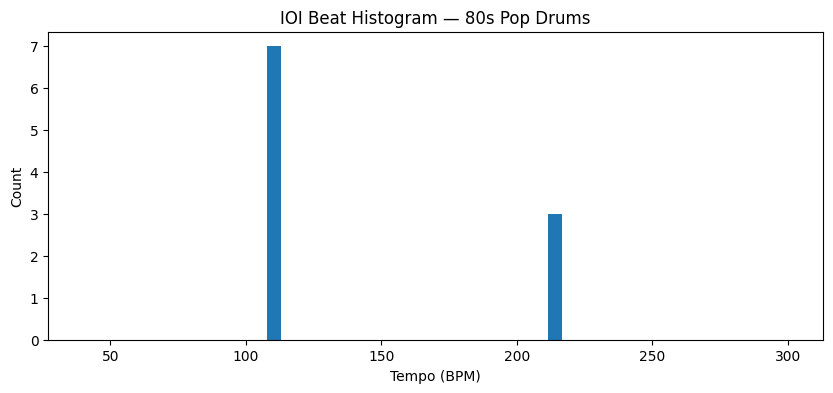

In [151]:
# Beat histogram from IOIs
ioi_bpms = 60 / iois
plt.figure(figsize=(10, 4))
plt.hist(ioi_bpms, bins=50, range=(40, 300))
plt.xlabel('Tempo (BPM)')
plt.ylabel('Count')
plt.title('IOI Beat Histogram — 80s Pop Drums')
plt.show()

2) Autocorrelation based Tempo
- Compute the autocorrelation of your novelty function
- Convert lag to BPMs (conside perceptual relevance)
- Crate a beat histogram to help you infer tempos

In [170]:
# --- Autocorrelation-Based Tempo ---

ac = librosa.autocorrelate(novelty)
ac = ac / ac.max()

lags = np.arange(len(ac))
lag_times = lags * hop_length / fs_drums  # convert lag frames → seconds

# Find highly correlated lag times (ignore lag=0 and lag=1)
points = np.where(ac > 0.3)[0]
points = points[points > 1]
t_pts = points * hop_length / fs_drums

# Differences between correlated lag times reveal periodicity
durs = np.diff(t_pts)
durs = np.round(durs, 3)
bpms = 60 / durs
mask = bpms < 400 # filter out unrealistic BPMs
bpms = bpms[mask]

num_counts = Counter(bpms)
top_n = num_counts.most_common(3)
print("Most common lag differences:", top_n)

for bpm, count in top_n:
    dur = 60 / bpm
    print(f"  Δt={dur:.3f}s  →  {bpm:.1f} BPM")

Most common lag differences: [(112.35955056179775, 2), (224.7191011235955, 2), (109.89010989010988, 2)]
  Δt=0.534s  →  112.4 BPM
  Δt=0.267s  →  224.7 BPM
  Δt=0.546s  →  109.9 BPM


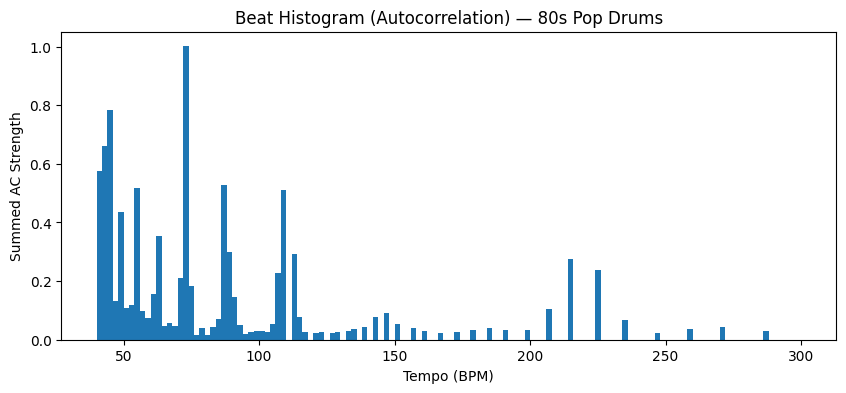

In [174]:
# Beat histogram from autocorrelation
# Bin BPM values into discrete buckets, weighting each by its AC strength
bpms = 60 / lag_times[1:]   # skip lag=0 to avoid divide-by-zero
strength = ac[1:]

bins = np.arange(40, 302, 2)  # 2-BPM-wide bins from 40–300
hist, edges = np.histogram(bpms, bins=bins, weights=strength)
centers = (edges[:-1] + edges[1:]) / 2

plt.figure(figsize=(10, 4))
plt.bar(centers, hist, width=2)
plt.xlabel('Tempo (BPM)')
plt.ylabel('Summed AC Strength')
plt.title('Beat Histogram (Autocorrelation) — 80s Pop Drums')
plt.show()


Estimate tempo using librosa.beat.tempo. How do your results compare?

Between autocorrelation and IOIs, which method is most stable? Which is most sensitive to onset errors Do the different files present different behaviors/accuracies?

In [175]:
# --- Compare all three tracks with librosa.beat.tempo ---

for title, x, fs in tracks:
    # Our novelty-based estimates
    energy, rmse, t = compute_features(x, fs)
    novelty = compute_novelty(rmse)

    # IOI estimate
    thresh = thresholds[title]
    peaks, _ = signal.find_peaks(novelty, height=thresh)
    peak_times = t[peaks]
    iois = np.diff(peak_times)
    ioi_bpms = 60 / iois
    ioi_estimate = np.median(ioi_bpms)

    # Autocorrelation estimate (pick the strongest non-zero lag in perceptual range 40-300 BPM)
    ac = librosa.autocorrelate(novelty)
    ac = ac / ac.max()
    lags = np.arange(len(ac))
    lag_times_s = lags * hop_length / fs
    # mask to perceptual BPM range
    valid = (lag_times_s[1:] > 0) & (60/lag_times_s[1:] >= 40) & (60/lag_times_s[1:] <= 300)
    best_lag = np.argmax(ac[1:][valid])
    valid_lags = lag_times_s[1:][valid]
    ac_estimate = 60 / valid_lags[best_lag]

    # Librosa estimate
    librosa_tempo = librosa.beat.tempo(y=x.astype(float), sr=fs)[0]

    print(f"{title}:")
    print(f"  IOI estimate:   {ioi_estimate:.1f} BPM")
    print(f"  ACF estimate:   {ac_estimate:.1f} BPM")
    print(f"  librosa.beat.tempo: {librosa_tempo:.1f} BPM")
    print()

80s Pop Drums:
  IOI estimate:   215.3 BPM
  ACF estimate:   73.8 BPM
  librosa.beat.tempo: 110.0 BPM

The Black Keys:
  IOI estimate:   265.2 BPM
  ACF estimate:   84.7 BPM
  librosa.beat.tempo: 166.7 BPM

Prelude C Maj:
  IOI estimate:   246.1 BPM
  ACF estimate:   246.1 BPM
  librosa.beat.tempo: 126.0 BPM



## Extension

Repeat the activities above but change the frame size and hop length. How does that impact your results?